# Primitive discretization demo

この notebook は、細かい仕様テストではなく「ユーザーが DSL に従って残差を書き、離散化して、有限次元の問題として解ける」ことを確認するための実用デモです。

細かい shape、guard、stencil exactness、`D(jnp.sin(x), "t")` / `jnp.sin(D(x, "t"))` の境界条件は `tests/dsl/test_primitives.py` で検証します。ここでは notebook を読む人が流れを追えることを優先します。

## 1. Setup

Repository root からでも `jupyter/` からでも実行できるように `python/` を import path に追加します。
既存 kernel で前の DSL を import 済みでも、この setup cell が repo の DSL module を読み直します。

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "True")


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "python" / "docomo_bt_management").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
repo_python = repo_root / "python"
if str(repo_python) not in sys.path:
    sys.path.insert(0, str(repo_python))

# Re-running this setup cell in an existing VS Code/Jupyter kernel must pick up
# the workspace implementation instead of a stale imported DSL module.
for module_name in [
    "docomo_bt_management.dsl.primitives",
    "docomo_bt_management.dsl",
    "docomo_bt_management",
]:
    sys.modules.pop(module_name, None)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from docomo_bt_management.dsl import D, DiscretizationRequest, discretization

plt.rcParams.update({"figure.dpi": 110})

## 2. ユーザーが書く残差

ユーザーが書く関数は `f(x, ..., t)` の形です。`D(..., "t", order=...)` だけが離散化 marker で、それ以外の `jnp.sin(x)` や四則演算は通常の配列計算として実行されます。

ここでは真の解を `x(t)=1+t^2` にして、非線形 residual が離散化された出力位置で 0 になる問題を作ります。ユーザーが指定するのは区間と点数だけで、生成された grid と `z` に必要な内部サンプル点は restorer が保持します。


In [2]:
def exact_solution(t):
    return 1.0 + t**2


def residual(x, t):
    exact = exact_solution(t)
    return D(x, "t", order=2) + jnp.sin(x) - (2.0 + jnp.sin(exact))


request = DiscretizationRequest(
    interval=(0.0, 1.0),
    points=12,
    scheme="central",
)
f_tilde, restore_blocks = discretization(residual, request)

z_exact = restore_blocks.pack(x=exact_solution)
residual_at_exact = np.asarray(f_tilde(z_exact), dtype=float)
blocks = restore_blocks(z_exact)

{
    "input_names": restore_blocks.names(),
    "f_tilde_shape": restore_blocks.f_tilde_shape,
    "z_shape": restore_blocks.z_shape,
    "grid_shape": tuple(restore_blocks.grid.shape),
    "x_block_shape": tuple(blocks["x"].shape),
    "x_output_shape": tuple(blocks.at_output("x").shape),
    "max_residual_at_exact_solution": float(np.linalg.norm(residual_at_exact, ord=np.inf)),
}


{'input_names': ('x',),
 'f_tilde_shape': (12,),
 'z_shape': (14,),
 'grid_shape': (12,),
 'x_block_shape': (14,),
 'x_output_shape': (12,),
 'max_residual_at_exact_solution': 2.842170943040401e-14}

## 3. 離散化後の問題を解く

`f_tilde(z)` は `restore_blocks.f_tilde_shape` の residual vector を返します。ここでは `restore_blocks.pack(...)` で作った参照 `z` の両端値を境界条件として足し、`scipy.optimize.root` で `z` を解きます。


In [3]:
def nonlinear_system(z_values):
    z_array = jnp.asarray(z_values, dtype=jnp.float64)
    ode_residual = np.asarray(f_tilde(z_array), dtype=float)
    boundary_residual = np.asarray(
        jnp.array([z_array[0] - z_exact[0], z_array[-1] - z_exact[-1]]),
        dtype=float,
    )
    return np.concatenate([ode_residual, boundary_residual])


initial_guess = np.asarray(
    z_exact + 0.05 * jnp.sin(jnp.arange(z_exact.size, dtype=jnp.float64)),
    dtype=float,
)
solution = root(nonlinear_system, initial_guess)
if not solution.success:
    raise RuntimeError(solution.message)

solution_z = jnp.asarray(solution.x, dtype=jnp.float64)
solution_blocks = restore_blocks(solution_z)
solution_on_output = np.asarray(solution_blocks.at_output("x"), dtype=float)
exact_on_output = np.asarray(blocks.at_output("x"), dtype=float)
final_residual = nonlinear_system(solution.x)

solve_summary = {
    "solver_success": bool(solution.success),
    "max_solution_error_on_output": float(np.max(np.abs(solution_on_output - exact_on_output))),
    "max_ode_residual": float(np.linalg.norm(final_residual[: restore_blocks.f_tilde_shape[0]], ord=np.inf)),
    "max_boundary_residual": float(np.linalg.norm(final_residual[restore_blocks.f_tilde_shape[0] :], ord=np.inf)),
}
solve_summary


{'solver_success': True,
 'max_solution_error_on_output': 9.681144774731365e-14,
 'max_ode_residual': 1.4370726830748026e-12,
 'max_boundary_residual': 0.0}

## 4. 診断プロット

左は `restore_blocks.grid` 上の解、右は同じ grid 上の `f_tilde` residual magnitude です。ユーザーコードは halo 点や出力 slice を手で組み立てず、restorer の grid、shape、output-aligned values だけを見ます。


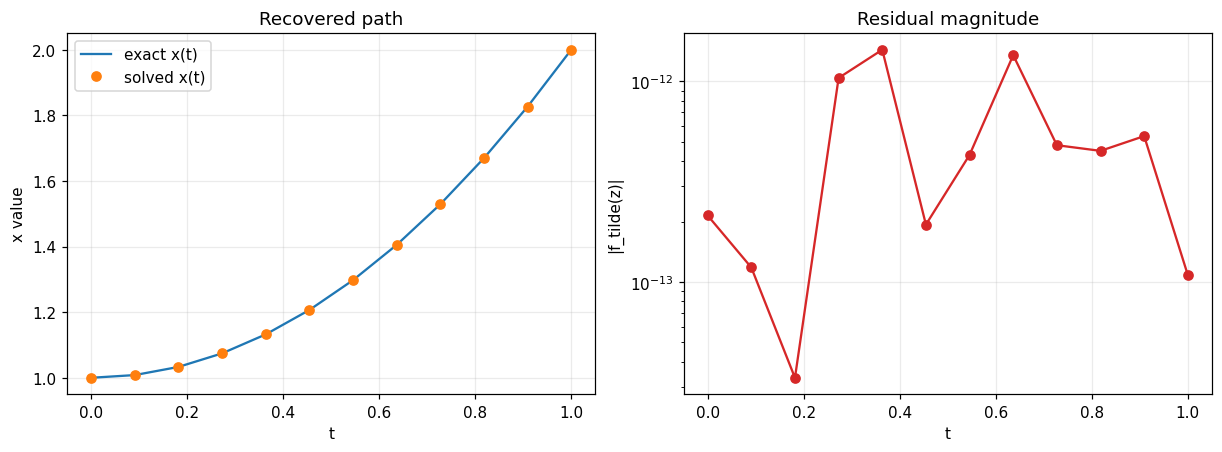

{'solver_success': True,
 'max_solution_error_on_output': 9.681144774731365e-14,
 'max_ode_residual': 1.4370726830748026e-12,
 'max_boundary_residual': 0.0}

In [4]:
output_grid = np.asarray(restore_blocks.grid, dtype=float)
ode_residual = final_residual[: restore_blocks.f_tilde_shape[0]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(output_grid, exact_on_output, color="tab:blue", label="exact x(t)")
axes[0].plot(output_grid, solution_on_output, "o", color="tab:orange", label="solved x(t)")
axes[0].set_title("Recovered path")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x value")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].semilogy(output_grid, np.maximum(np.abs(ode_residual), 1e-16), "o-", color="tab:red")
axes[1].set_title("Residual magnitude")
axes[1].set_xlabel("t")
axes[1].set_ylabel("|f_tilde(z)|")
axes[1].grid(True, alpha=0.25)

plt.show()
solve_summary


## 5. 式を `D(...)` に入れる例

`D(jnp.sin(x), "t")` のように、ユーザー式を `D` の中に置くこともできます。離散化中は `sin(x)` を内部サンプル付き配列として評価し、その配列に有限差分を適用します。


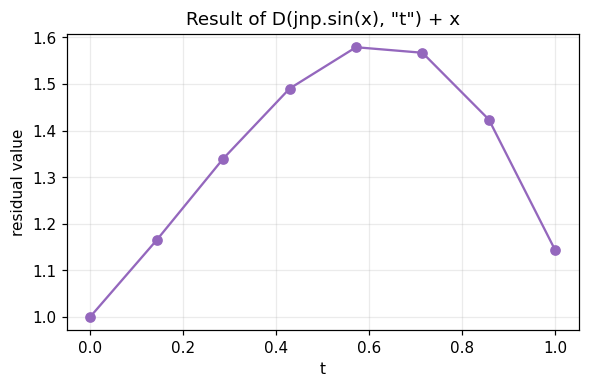

{'f_tilde_shape': (8,),
 'z_shape': (10,),
 'grid_shape': (8,),
 'result_preview': [1.0,
  1.164801,
  1.339504,
  1.490235,
  1.579111,
  1.567197,
  1.423658,
  1.142546]}

In [5]:
def expression_residual(x, t):
    return D(jnp.sin(x), "t") + x


expression_request = DiscretizationRequest(
    interval=(0.0, 1.0),
    points=8,
    scheme="central",
)
expression_tilde, expression_blocks = discretization(
    expression_residual,
    expression_request,
)
expression_z = expression_blocks.pack(x=exact_solution)
expression_values = np.asarray(expression_tilde(expression_z), dtype=float)
expression_grid = np.asarray(expression_blocks.grid, dtype=float)

plt.figure(figsize=(6, 3.5))
plt.plot(expression_grid, expression_values, "o-", color="tab:purple")
plt.title('Result of D(jnp.sin(x), "t") + x')
plt.xlabel("t")
plt.ylabel("residual value")
plt.grid(True, alpha=0.25)
plt.show()

{
    "f_tilde_shape": expression_blocks.f_tilde_shape,
    "z_shape": expression_blocks.z_shape,
    "grid_shape": tuple(expression_blocks.grid.shape),
    "result_preview": expression_values.round(6).tolist(),
}
